# Notebook 05: Monte Carlo Methods

**Series:** Reinforcement Learning Basics (5/20)

---

## 1. Why Monte Carlo?

**Key insight:** We don't need a model! Learn directly from **episodes of experience**.

MC methods estimate value functions by **averaging sample returns**.

| Property | DP | MC |
|----------|----|----|
| Model needed? | Yes | **No** |
| Bootstrapping? | Yes | **No** |
| Works online? | Yes | **No** (need complete episodes) |
| Bias | None | **None** (unbiased) |
| Variance | Low | **High** |

## 2. MC Prediction

**Goal:** Estimate $V^\pi(s) = \mathbb{E}_\pi[G_t | S_t = s]$

### First-Visit MC
For each episode:
1. Generate episode: $S_0, A_0, R_1, S_1, A_1, R_2, \ldots, S_T$
2. For each state $s$ appearing in the episode (first visit only):
   - Compute return $G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}$
   - Append $G_t$ to $\text{Returns}(s)$
3. $V(s) = \text{average}(\text{Returns}(s))$

### Every-Visit MC
Same, but count **every** visit to $s$, not just the first.

### Incremental Update (more practical)
$$V(S_t) \leftarrow V(S_t) + \alpha \Big[ G_t - V(S_t) \Big]$$

**Why it works:** By the **Law of Large Numbers**, the sample average converges to the expected value.

## 3. MC Control (On-Policy)

Use **$\varepsilon$-greedy** policy for exploration:

$$\pi(a|s) = \begin{cases} 1 - \varepsilon + \frac{\varepsilon}{|\mathcal{A}|} & \text{if } a = \arg\max_a Q(s,a) \\ \frac{\varepsilon}{|\mathcal{A}|} & \text{otherwise} \end{cases}$$

## 4. Off-Policy MC: Importance Sampling

Learn about target policy $\pi$ from data generated by behavior policy $b$.

**Importance Sampling Ratio:**
$$\rho_{t:T-1} = \prod_{k=t}^{T-1} \frac{\pi(A_k|S_k)}{b(A_k|S_k)}$$

**Ordinary IS:** $V(s) = \frac{\sum_{t \in \mathcal{T}(s)} \rho_{t:T(t)-1} G_t}{|\mathcal{T}(s)|}$ — unbiased but high variance

**Weighted IS:** $V(s) = \frac{\sum_{t \in \mathcal{T}(s)} \rho_{t:T(t)-1} G_t}{\sum_{t \in \mathcal{T}(s)} \rho_{t:T(t)-1}}$ — biased but much lower variance

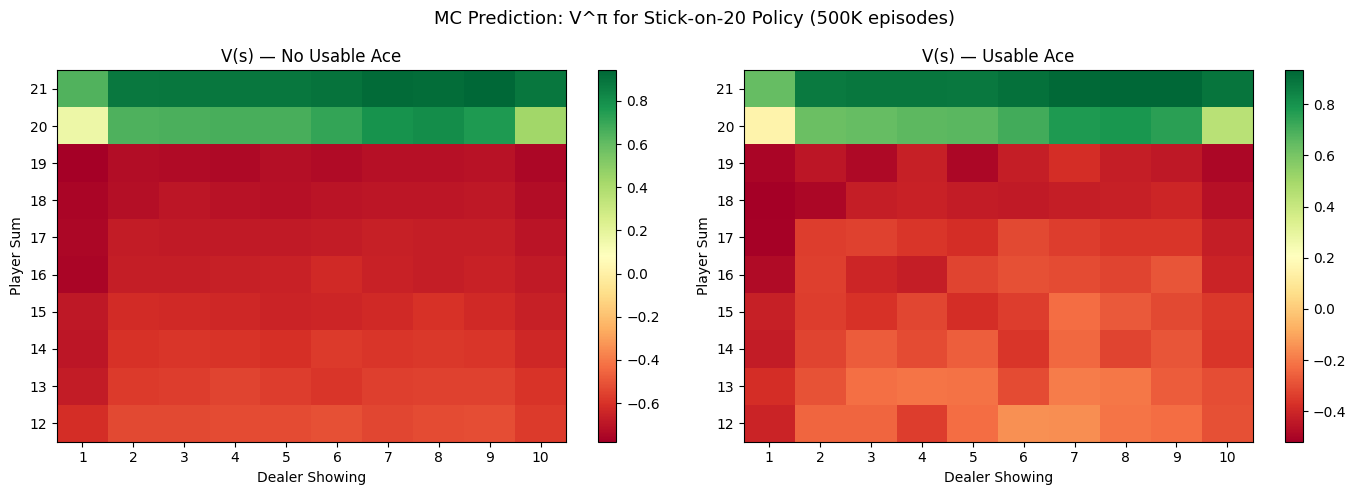

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Blackjack Environment
# ============================================

def draw_card():
    card = min(np.random.randint(1, 14), 10)
    return card

def usable_ace(hand):
    return 1 in hand and sum(hand) + 10 <= 21

def hand_value(hand):
    val = sum(hand)
    if usable_ace(hand):
        val += 10
    return val

def play_blackjack(policy, initial_state=None):
    """Play one episode of blackjack. Returns list of (state, action, reward)."""
    # Deal
    player = [draw_card(), draw_card()]
    dealer_showing = draw_card()
    dealer_hidden = draw_card()

    trajectory = []

    # Player's turn
    while True:
        p_sum = hand_value(player)
        if p_sum > 21:
            trajectory.append(((p_sum, dealer_showing, usable_ace(player)), None, -1))
            return trajectory
        if p_sum < 12:
            player.append(draw_card())
            continue
        state = (p_sum, dealer_showing, usable_ace(player))
        action = policy(state)  # 0 = stick, 1 = hit
        trajectory.append((state, action, None))
        if action == 0:
            break
        player.append(draw_card())

    # Dealer's turn (hits until >= 17)
    dealer = [dealer_showing, dealer_hidden]
    while hand_value(dealer) < 17:
        dealer.append(draw_card())

    p_val = hand_value(player)
    d_val = hand_value(dealer)

    if d_val > 21 or p_val > d_val:
        reward = 1
    elif p_val < d_val:
        reward = -1
    else:
        reward = 0

    # Update last entry with reward
    trajectory[-1] = (trajectory[-1][0], trajectory[-1][1], reward)
    return trajectory

# ============================================
# First-Visit MC Prediction
# ============================================

def mc_prediction(policy, n_episodes=500000, gamma=1.0):
    V = {}
    returns_count = {}
    returns_sum = {}

    for _ in range(n_episodes):
        episode = play_blackjack(policy)
        states_in_episode = set()
        G = 0
        for t in range(len(episode) - 1, -1, -1):
            state, action, reward = episode[t]
            if reward is not None:
                G = reward + gamma * G
            if state not in states_in_episode and state[0] <= 21:
                states_in_episode.add(state)
                returns_sum[state] = returns_sum.get(state, 0) + G
                returns_count[state] = returns_count.get(state, 0) + 1
                V[state] = returns_sum[state] / returns_count[state]
    return V

# Policy: stick on 20 or 21
def simple_policy(state):
    return 0 if state[0] >= 20 else 1

V = mc_prediction(simple_policy, n_episodes=500000)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, has_ace in enumerate([False, True]):
    grid = np.zeros((10, 10))
    for p_sum in range(12, 22):
        for d_show in range(1, 11):
            state = (p_sum, d_show, has_ace)
            grid[p_sum - 12, d_show - 1] = V.get(state, 0)
    im = axes[idx].imshow(grid, cmap='RdYlGn', origin='lower', aspect='auto')
    axes[idx].set_xlabel('Dealer Showing')
    axes[idx].set_ylabel('Player Sum')
    axes[idx].set_xticks(range(10))
    axes[idx].set_xticklabels(range(1, 11))
    axes[idx].set_yticks(range(10))
    axes[idx].set_yticklabels(range(12, 22))
    axes[idx].set_title(f'V(s) — {"Usable" if has_ace else "No Usable"} Ace')
    plt.colorbar(im, ax=axes[idx])
plt.suptitle('MC Prediction: V^π for Stick-on-20 Policy (500K episodes)', fontsize=13)
plt.tight_layout()
plt.show()

## Summary

| Method | Formula | Properties |
|--------|---------|------------|
| **First-Visit MC** | $V(s) = \text{avg}(G_t)$ for first visits | Unbiased, high variance |
| **Incremental MC** | $V(s) \leftarrow V(s) + \alpha[G_t - V(s)]$ | Online-ready |
| **$\varepsilon$-greedy MC** | Explore with probability $\varepsilon$ | On-policy control |
| **Importance Sampling** | Weight by $\rho = \prod \pi/b$ | Off-policy |

**Next:** Notebook 06 — Temporal Difference Learning